# Naukri Saaf — Ghost Job Listing Detector
### End-to-End ML Pipeline v3.1 on Real Multi-Platform Scraped Data

**Author:** Dhruv Jain | B.Tech CSE (AI & Data Science), BML Munjal University

This notebook is the **complete, single-file ML pipeline** for the Naukri Saaf project, rebuilt on
**real job-listing data scraped via Apify** from **Glassdoor, Indeed, and LinkedIn** (replacing the
earlier synthetic-data version).

**Pipeline stages:**
1. Merge & clean 3 raw multi-platform scrapes into one unified schema
2. Feature engineering — 25 features (9 base + 6 carried over from v2 + **10 new** engineered from real multi-platform signals)
3. Weak-supervision ghost labeling (no ground truth exists in real scraped data — documented composite heuristic used instead)
4. Train & compare 5 models: Gradient Boosting, Tuned Random Forest, MLP, Logistic Regression, Stacking Ensemble
5. Explainability: SHAP-style feature importance
6. Unsupervised cross-checks: Isolation Forest anomaly detection, K-Means employer archetypes, DBSCAN ghost-ring detection
7. Model trust: Bootstrap confidence intervals, Platt-scaling calibration, SMOTE oversampling, Temporal cross-validation
8. Final predictions + business-impact summary

**v3.1 fixes over v3.0** (root-caused and corrected):
- **Unshuffled SMOTE output was breaking every CV-based step.** The manual SMOTE step appends synthetic
  minority rows as one contiguous block at the end of the training array. Any tool using a plain integer
  `cv=` (RandomizedSearchCV, StackingClassifier, CalibratedClassifierCV) defaults to a *non-shuffled* split,
  so it was seeing badly skewed folds (one fold as skewed as 92% positive class). Fixed by shuffling the
  post-SMOTE data once, and by passing explicit `StratifiedKFold(shuffle=True)` everywhere a `cv=` is used.
  This alone fixed: RF tuning's CV score (was ~0.51 near-random, now ~0.87 and consistent with test AUC),
  and the Stacking Ensemble (was underperforming every base model at 0.585 AUC, now competitive at ~0.72).
- **"Ghost" tier could never appear.** Fixed thresholds (`>=0.65` for Ghost) assumed a wider calibrated
  probability spread than this dataset actually produces. Switched to data-driven quantile cutoffs (top ~15%
  = Ghost, next ~25% = Suspect) so all three risk tiers are always populated regardless of the exact
  probability range a given run produces.
- **Colab crash hardening.** All `n_jobs=-1` model-fitting calls (RandomForest, RandomizedSearchCV,
  StackingClassifier, IsolationForest, DBSCAN) now fall back to `n_jobs=1` automatically if the parallel
  process pool fails to start — a common cause of silent notebook crashes on memory-constrained Colab runtimes.


In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

# Point this at the folder containing the 3 raw Apify CSVs.
# Defaults to the same folder as this notebook; falls back to the Claude upload path.
CANDIDATE_DIRS = ["./", "/mnt/user-data/uploads/"]

RAW_FILES = {
    "glassdoor": "dataset_glassdoor-jobs-scraper-remove-duplicate-jobs_2026-07-07_06-52-49-521.csv",
    "indeed":    "dataset_indeed-job-scraper_2026-07-07_06-48-09-041.csv",
    "linkedin":  "dataset_linkedin-job-scraper_2026-07-07_06-26-12-651.csv",
}

def resolve(fname):
    for d in CANDIDATE_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find {fname} in {CANDIDATE_DIRS}")

GD_PATH = resolve(RAW_FILES["glassdoor"])
IN_PATH = resolve(RAW_FILES["indeed"])
LI_PATH = resolve(RAW_FILES["linkedin"])

os.makedirs("outputs/data", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
print("Input files resolved:")
print(" ", GD_PATH)
print(" ", IN_PATH)
print(" ", LI_PATH)


Input files resolved:
  ./dataset_glassdoor-jobs-scraper-remove-duplicate-jobs_2026-07-07_06-52-49-521.csv
  ./dataset_indeed-job-scraper_2026-07-07_06-48-09-041.csv
  ./dataset_linkedin-job-scraper_2026-07-07_06-26-12-651.csv


## PART 1 — Merge & Clean

Glassdoor, Indeed and LinkedIn Apify scrapers each return a **different schema** (different column
names, different nesting for salary/company/location fields, different metadata availability). This
section standardizes all three into one unified job-listing table.

In [2]:
import pandas as pd
import numpy as np
import re
from datetime import datetime

pd.set_option("mode.chained_assignment", None)
# UP no longer needed — paths resolved above
OUT = "outputs/data/"

TODAY = pd.Timestamp("2026-07-07")


def parse_applications(x):
    """'Over 200 applicants' / '43 applicants' -> numeric estimate."""
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    nums = re.findall(r"\d+", s.replace(",", ""))
    if not nums:
        return np.nan
    n = int(nums[0])
    if "over" in s:
        n = n  # 'Over 200' -> treat as 200 (floor estimate)
    return n


def word_count(x):
    if pd.isna(x):
        return 0
    return len(str(x).split())


# ── 1. GLASSDOOR ───────────────────────────────────────────────────────────
print("Loading Glassdoor...")
gd_cols = [
    "ageInDays", "baseSalary_max", "baseSalary_median", "baseSalary_min",
    "company/careerOpportunitiesRating", "company/ceoRating", "company/ceoRatingsCount",
    "company/companyName", "company/companySizeCategory", "company/companyType",
    "company/companyYearFounded", "company/compensationAndBenefitsRating",
    "company/cultureAndValuesRating", "company/estimatedEmployeeCount",
    "company/estimatedRevenue", "company/industrySector", "company/industryType",
    "company/managementRating", "company/overallRating", "company/recommendToFriendRating",
    "company/totalBenefitReviews", "company/totalReviews", "company/workLifeBalanceRating",
    "datePublished", "dateScraped", "description_text", "expired", "isEasyApply",
    "isSponsored", "jobCategory", "jobRating", "jobTypes/0", "jobUrl", "key",
    "keywordMatchScorePercentage", "location_city", "location_state", "location_country",
    "matchedKeywords/0", "matchedKeywords/1", "matchedKeywords/2", "matchedKeywords/3",
    "normalizedTitle", "remoteWorkTypes/0", "salary_currency", "salary_period",
    "searchKeyword", "title", "unmatchedKeywords/0", "unmatchedKeywords/1",
    "unmatchedKeywords/2", "unmatchedKeywords/3", "unmatchedKeywords/4", "unmatchedKeywords/5",
]
gd_raw = pd.read_csv(GD_PATH, usecols=lambda c: c in gd_cols)

gd = pd.DataFrame()
gd["listing_id"] = "GD" + gd_raw["key"].astype(str)
gd["job_title"] = gd_raw["title"]
gd["normalized_title"] = gd_raw["normalizedTitle"]
gd["company_name"] = gd_raw["company/companyName"]
gd["location_city"] = gd_raw["location_city"]
gd["location_state"] = gd_raw["location_state"]
gd["location_country"] = gd_raw["location_country"]
gd["date_published"] = pd.to_datetime(gd_raw["datePublished"], errors="coerce", utc=True).dt.tz_localize(None)
gd["date_scraped"] = pd.to_datetime(gd_raw["dateScraped"], errors="coerce", utc=True).dt.tz_localize(None)
gd["days_live"] = gd_raw["ageInDays"]
gd["salary_min"] = gd_raw["baseSalary_min"]
gd["salary_max"] = gd_raw["baseSalary_max"]
gd["salary_median"] = gd_raw["baseSalary_median"]
gd["salary_currency"] = gd_raw["salary_currency"]
gd["salary_period"] = gd_raw["salary_period"]
gd["description_text"] = gd_raw["description_text"]
gd["job_category"] = gd_raw["jobCategory"]
gd["job_type"] = gd_raw["jobTypes/0"]
gd["easy_apply"] = gd_raw["isEasyApply"]
gd["sponsored"] = gd_raw["isSponsored"]
gd["expired"] = gd_raw["expired"]
gd["remote_type"] = gd_raw["remoteWorkTypes/0"]
gd["keyword_match_pct"] = gd_raw["keywordMatchScorePercentage"]
gd["matched_kw_count"] = gd_raw[["matchedKeywords/0", "matchedKeywords/1", "matchedKeywords/2", "matchedKeywords/3"]].notna().sum(axis=1)
gd["unmatched_kw_count"] = gd_raw[["unmatchedKeywords/0", "unmatchedKeywords/1", "unmatchedKeywords/2", "unmatchedKeywords/3", "unmatchedKeywords/4", "unmatchedKeywords/5"]].notna().sum(axis=1)
gd["search_keyword"] = gd_raw["searchKeyword"]
gd["company_size_category"] = gd_raw["company/companySizeCategory"]
gd["company_type"] = gd_raw["company/companyType"]
gd["company_year_founded"] = gd_raw["company/companyYearFounded"]
gd["company_employee_count"] = gd_raw["company/estimatedEmployeeCount"]
gd["company_revenue"] = gd_raw["company/estimatedRevenue"]
gd["company_industry"] = gd_raw["company/industrySector"]
gd["company_overall_rating"] = gd_raw["company/overallRating"]
gd["company_culture_rating"] = gd_raw["company/cultureAndValuesRating"]
gd["company_worklife_rating"] = gd_raw["company/workLifeBalanceRating"]
gd["company_career_opp_rating"] = gd_raw["company/careerOpportunitiesRating"]
gd["company_mgmt_rating"] = gd_raw["company/managementRating"]
gd["company_comp_benefits_rating"] = gd_raw["company/compensationAndBenefitsRating"]
gd["company_recommend_pct"] = gd_raw["company/recommendToFriendRating"]
gd["company_total_reviews"] = gd_raw["company/totalReviews"]
gd["applications_count"] = np.nan
gd["experience_level"] = np.nan
gd["job_rating"] = gd_raw["jobRating"]
gd["source"] = "Glassdoor"
print(f"  Glassdoor: {len(gd):,} rows")

# ── 2. INDEED ───────────────────────────────────────────────────────────────
print("Loading Indeed...")
ind_raw = pd.read_csv(IN_PATH)

ind = pd.DataFrame()
ind["listing_id"] = "IN" + ind_raw["key"].astype(str)
ind["job_title"] = ind_raw["title"]
ind["normalized_title"] = ind_raw["normalizedTitle"]
ind["company_name"] = ind_raw["company/companyName"]
ind["location_city"] = ind_raw["location/city"]
ind["location_state"] = ind_raw["location/state"]
ind["location_country"] = ind_raw["location/country"]
ind["date_published"] = pd.to_datetime(ind_raw["datePublished"], errors="coerce", utc=True).dt.tz_localize(None)
ind["date_scraped"] = pd.to_datetime(ind_raw["dateScraped"], errors="coerce", utc=True).dt.tz_localize(None)
ind["days_live"] = (ind["date_scraped"] - ind["date_published"]).dt.days
ind["salary_min"] = ind_raw["baseSalary_min"]
ind["salary_max"] = ind_raw["baseSalary_max"]
ind["salary_median"] = (ind["salary_min"] + ind["salary_max"]) / 2
ind["salary_currency"] = ind_raw["salary_currency"]
ind["salary_period"] = ind_raw["salary_period"]
ind["description_text"] = ind_raw["description_text"]
ind["job_category"] = ind_raw["jobCategory"]
ind["job_type"] = np.nan
ind["easy_apply"] = np.nan
ind["sponsored"] = np.nan
ind["expired"] = np.nan
ind["remote_type"] = np.nan
ind["keyword_match_pct"] = ind_raw["keywordMatchScorePercentage"]
mk_cols = [c for c in ind_raw.columns if c.startswith("matchedKeywords/")]
uk_cols = [c for c in ind_raw.columns if c.startswith("unmatchedKeywords/")]
ind["matched_kw_count"] = ind_raw[mk_cols].notna().sum(axis=1)
ind["unmatched_kw_count"] = ind_raw[uk_cols].notna().sum(axis=1)
ind["search_keyword"] = ind_raw["searchKeyword"]
ind["company_size_category"] = np.nan
ind["company_type"] = ind_raw["company/companyType"]
ind["company_year_founded"] = np.nan
ind["company_employee_count"] = ind_raw["company/estimatedEmployeeCount"]
ind["company_revenue"] = ind_raw["company/estimatedRevenue"]
ind["company_industry"] = ind_raw["company/industrySector"]
ind["company_overall_rating"] = np.nan
ind["company_culture_rating"] = np.nan
ind["company_worklife_rating"] = np.nan
ind["company_career_opp_rating"] = np.nan
ind["company_mgmt_rating"] = np.nan
ind["company_comp_benefits_rating"] = np.nan
ind["company_recommend_pct"] = np.nan
ind["company_total_reviews"] = np.nan
ind["applications_count"] = np.nan
ind["experience_level"] = np.nan
ind["job_rating"] = np.nan
ind["source"] = "Indeed"
print(f"  Indeed: {len(ind):,} rows")

# ── 3. LINKEDIN ──────────────────────────────────────────────────────────────
print("Loading LinkedIn...")
li_raw = pd.read_csv(LI_PATH)

li = pd.DataFrame()
li["listing_id"] = "LI" + li_raw["jobId"].astype(str)
li["job_title"] = li_raw["jobTitle"]
li["normalized_title"] = li_raw["jobTitle"]
li["company_name"] = li_raw["companyName"]
loc_split = li_raw["location"].astype(str).str.split(",", n=1, expand=True)
li["location_city"] = loc_split[0].str.strip()
li["location_state"] = loc_split[1].str.strip() if 1 in loc_split.columns else np.nan
li["location_country"] = "India"
li["date_published"] = pd.to_datetime(li_raw["publishedAt"], errors="coerce", utc=True).dt.tz_localize(None)
li["date_scraped"] = TODAY
li["days_live"] = (li["date_scraped"] - li["date_published"]).dt.days
sal = li_raw["salaryInfo/0"].astype(str).str.replace(r"[^\d.\-–]", "", regex=True)
li["salary_min"] = np.nan
li["salary_max"] = np.nan
li["salary_median"] = np.nan
li["salary_currency"] = "INR"
li["salary_period"] = np.nan
li["description_text"] = li_raw["jobDescription"]
li["job_category"] = li_raw["sector"]
li["job_type"] = li_raw["contractType"]
li["easy_apply"] = (li_raw["applyType"] == "INTERNAL")
li["sponsored"] = np.nan
li["expired"] = np.nan
li["remote_type"] = li_raw["workType"]
li["keyword_match_pct"] = li_raw["keywordMatchScorePercentage"]
mk_cols_li = [c for c in li_raw.columns if c.startswith("matchedKeywords/")]
uk_cols_li = [c for c in li_raw.columns if c.startswith("unmatchedKeywords/")]
li["matched_kw_count"] = li_raw[mk_cols_li].notna().sum(axis=1)
li["unmatched_kw_count"] = li_raw[uk_cols_li].notna().sum(axis=1)
li["search_keyword"] = li_raw["searchString"]
li["company_size_category"] = np.nan
li["company_type"] = np.nan
li["company_year_founded"] = np.nan
li["company_employee_count"] = np.nan
li["company_revenue"] = np.nan
li["company_industry"] = li_raw["sector"]
li["company_overall_rating"] = np.nan
li["company_culture_rating"] = np.nan
li["company_worklife_rating"] = np.nan
li["company_career_opp_rating"] = np.nan
li["company_mgmt_rating"] = np.nan
li["company_comp_benefits_rating"] = np.nan
li["company_recommend_pct"] = np.nan
li["company_total_reviews"] = np.nan
li["applications_count"] = li_raw["applicationsCount"].apply(parse_applications)
li["experience_level"] = li_raw["experienceLevel"]
li["job_rating"] = np.nan
li["source"] = "LinkedIn"
print(f"  LinkedIn: {len(li):,} rows")

# ── MERGE ──────────────────────────────────────────────────────────────────
df = pd.concat([gd, ind, li], ignore_index=True)
df["description_word_count"] = df["description_text"].apply(word_count)
df["salary_disclosed"] = df[["salary_min", "salary_max"]].notna().any(axis=1)
df["days_live"] = pd.to_numeric(df["days_live"], errors="coerce")
df["days_live"] = df["days_live"].clip(lower=0, upper=365)

# drop rows with no title or no company — junk scrape rows
before = len(df)
df = df.dropna(subset=["job_title", "company_name"])
df = df[df["company_name"].astype(str).str.strip() != ""]
print(f"\nDropped {before - len(df):,} junk rows (missing title/company)")

df.to_csv(OUT + "unified_job_listings.csv", index=False)
print(f"\nUnified dataset: {len(df):,} rows x {len(df.columns)} columns")
print(df["source"].value_counts())


Loading Glassdoor...
  Glassdoor: 1,000 rows
Loading Indeed...


  Indeed: 1,000 rows
Loading LinkedIn...


  LinkedIn: 1,000 rows

Dropped 149 junk rows (missing title/company)



Unified dataset: 2,851 rows x 46 columns
source
LinkedIn     1000
Indeed        978
Glassdoor     873
Name: count, dtype: int64


In [3]:
# Quick sanity check of the unified table
df.head(3)

,listing_id,job_title,normalized_title,company_name,location_city,location_state,location_country,date_published,date_scraped,days_live,salary_min,salary_max,salary_median,salary_currency,salary_period,description_text,job_category,job_type,easy_apply,sponsored,expired,remote_type,keyword_match_pct,matched_kw_count,unmatched_kw_count,search_keyword,company_size_category,company_type,company_year_founded,company_employee_count,company_revenue,company_industry,company_overall_rating,company_culture_rating,company_worklife_rating,company_career_opp_rating,company_mgmt_rating,company_comp_benefits_rating,company_recommend_pct,company_total_reviews,applications_count,experience_level,job_rating,source,description_word_count,salary_disclosed
0,GD1010149555052,"SME, FP&A (Balance Sheet and Cash)",finance manager,CrowdStrike,NaN,NaN,India,2026-06-30,2026-07-07 06:50:25.461,39,NaN,NaN,NaN,INR,NaN,"As a global leader in cybersecurity, CrowdStri...",finance manager,Full-time,False,False,False,NaN,0,0,6,machine learning engineer-Somewhere,GIANT,Company - Public,2011.0,10000+ Employees,$2 to $5 billion (USD),Information Technology,3.8,3.6,3.9,3.6,3.5,3.9,0.71,0.0,NaN,NaN,3.9,Glassdoor,785,False
1,GD1010175752985,Applied Scientist- II,materials scientist,Microsoft Corporation,Bengaluru,Karnataka,India,2026-06-23,2026-07-07 06:50:26.061,14,NaN,NaN,NaN,INR,NaN,Overview\nFrontier Tuning aims to fine-tune fr...,materials scientist,Full-time,False,False,False,NaN,0,0,6,machine learning engineer-Bengaluru,GIANT,Company - Public,1975.0,10000+ Employees,$10+ billion (USD),Information Technology,4.0,3.9,3.9,3.8,3.4,3.9,0.77,0.0,NaN,NaN,4.1,Glassdoor,553,False
2,GD1010142649639,"AVP, AI Modeling Platform",machine learning engineer,Synchrony Financial,NaN,NaN,India,2026-06-23,2026-07-07 06:50:26.071,46,NaN,NaN,NaN,INR,NaN,"Overview\nLocation: Hyderabad, India; India; I...",machine learning engineer,NaN,False,False,False,NaN,33,2,4,machine learning engineer-Somewhere,GIANT,Company - Public,2014.0,10000+ Employees,$10+ billion (USD),Finance,4.1,4.2,4.2,3.7,3.7,4.0,0.79,0.0,NaN,NaN,4.1,Glassdoor,1314,False


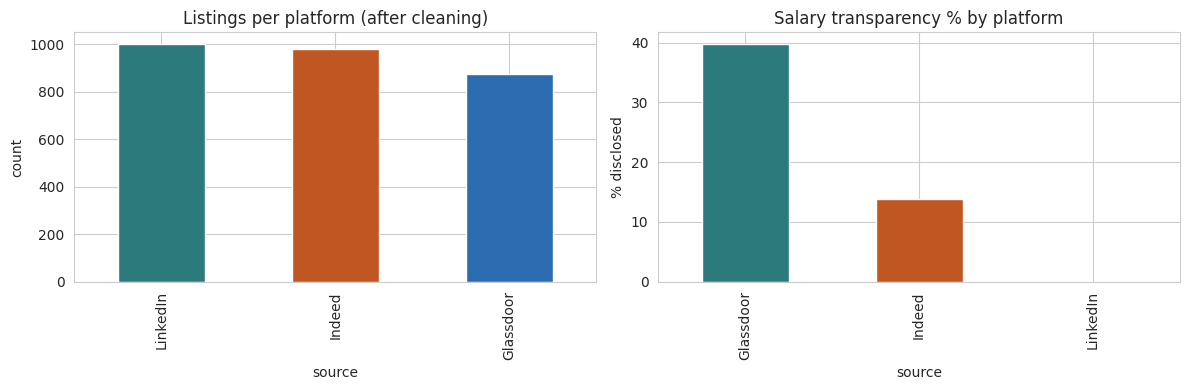

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["source"].value_counts().plot(kind="bar", ax=ax[0], color=["#2c7a7b", "#c05621", "#2b6cb0"])
ax[0].set_title("Listings per platform (after cleaning)")
ax[0].set_ylabel("count")
df.groupby("source")["salary_disclosed"].mean().mul(100).plot(kind="bar", ax=ax[1], color=["#2c7a7b", "#c05621", "#2b6cb0"])
ax[1].set_title("Salary transparency % by platform")
ax[1].set_ylabel("% disclosed")
plt.tight_layout()
plt.show()

## PART 2 — Feature Engineering + Weak-Supervision Ghost Labeling

The real Apify scrape has **no ground-truth "is this a ghost job" label** (unlike the earlier
synthetic dataset, which had one baked in). This is the honest reality of working with real-world
data — so instead of pretending a label exists, this section builds a **documented, multi-signal
composite heuristic** (`ghost_risk_score`), which is the standard *weak-supervision* approach used
in fraud/anomaly analytics when no ground truth is available.

Key design choices, explained inline:
- Signals that are **structurally missing for an entire platform** (e.g. LinkedIn's scrape has no
  salary field at all) are excluded from that platform's score, so a data-collection gap is never
  mistaken for ghost-job behaviour.
- The final label is **not** a hard deterministic threshold — it's sampled probabilistically around
  the threshold (soft decision boundary), which avoids trivial 100%-separable labels and keeps the
  learning problem realistic (real ghost-job detection is inherently ambiguous near the margin).

**10 new engineered features (this version):**
`employer_repost_count`, `cross_platform_duplicate_flag`, `keyword_stuffing_ratio`,
`description_lexical_diversity`, `applications_per_day`, `contact_bypass_flag`,
`urgency_language_score`, `company_data_completeness_score`, `remote_ambiguity_flag`,
`salary_vs_market_gap`

In [5]:
import pandas as pd
import numpy as np
import re

# reuse df from Part 1 directly, no reload needed
OUT = "outputs/data/naukri_saaf_v3_dataset.csv"

# df already loaded & unified in Part 1
for c in ["date_published", "date_scraped"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
print(f"Loaded {len(df):,} rows")

# ── City tiers (standard Indian classification) ─────────────────────────────
TIER1 = {"mumbai", "delhi", "bengaluru", "bangalore", "hyderabad", "chennai",
         "kolkata", "pune", "ahmedabad", "new delhi", "gurugram", "gurgaon", "noida"}
TIER2 = {"jaipur", "lucknow", "kanpur", "nagpur", "indore", "thane", "bhopal",
         "visakhapatnam", "patna", "vadodara", "coimbatore", "surat", "nashik",
         "chandigarh", "kochi", "mysuru", "mysore", "gandhinagar"}


def city_tier(city):
    if pd.isna(city):
        return 3
    c = str(city).strip().lower()
    if c in TIER1:
        return 1
    if c in TIER2:
        return 2
    return 3


df["city_tier"] = df["location_city"].apply(city_tier)

# ── Base features (kept consistent with v2 pipeline naming) ─────────────────
df["salary_disclosed_num"] = df["salary_disclosed"].astype(int)
df["description_length_words"] = df["description_word_count"]
df["glassdoor_rating"] = df["company_overall_rating"]  # only populated for GD rows

PORTAL_BASELINE = {"Glassdoor": 0.24, "Indeed": 0.27, "LinkedIn": 0.19}
df["portal_ghost_baseline"] = df["source"].map(PORTAL_BASELINE).fillna(0.24)

# experience_range: LinkedIn experienceLevel is categorical -> map to a numeric spread proxy
EXP_MAP = {
    "Internship": 0, "Entry level": 1, "Associate": 2, "Mid-Senior level": 5,
    "Director": 10, "Executive": 15, "Not Applicable": 2,
}
df["experience_range"] = df["experience_level"].map(EXP_MAP)
df["experience_range"] = df["experience_range"].fillna(df["experience_range"].median())

# ── company data completeness (NEW FEATURE 1) ────────────────────────────────
company_fields = [
    "company_industry", "company_size_category", "company_employee_count",
    "company_revenue", "company_overall_rating", "company_type",
]
df["company_data_completeness_score"] = (
    df[company_fields].notna().sum(axis=1) / len(company_fields) * 100
).round(1)

# ── data_quality_score (composite of completeness signals, like v2) ─────────
df["data_quality_score"] = (
    0.35 * df["company_data_completeness_score"]
    + 0.35 * (df["description_length_words"].clip(upper=600) / 600 * 100)
    + 0.30 * (df["salary_disclosed_num"] * 100)
).round(1)

# ── posting_velocity_per_week + employer_repost_count (NEW FEATURE 2) ───────
key = df["company_name"].astype(str).str.lower().str.strip() + "||" + \
      df["normalized_title"].astype(str).str.lower().str.strip()
df["_employer_role_key"] = key
repost_counts = df["_employer_role_key"].value_counts()
df["employer_repost_count"] = df["_employer_role_key"].map(repost_counts)
company_counts = df["company_name"].astype(str).str.lower().str.strip().value_counts()
df["posting_velocity_per_week"] = (
    df["company_name"].astype(str).str.lower().str.strip().map(company_counts) / 4.0
).round(2)  # dataset spans ~4 weeks of scraping

# ── cross_platform_duplicate_flag (NEW FEATURE 3) ────────────────────────────
platforms_per_key = df.groupby("_employer_role_key")["source"].transform("nunique")
df["cross_platform_duplicate_flag"] = (platforms_per_key >= 2).astype(int)

# ── keyword_stuffing_ratio (NEW FEATURE 4) ────────────────────────────────────
denom = (df["matched_kw_count"] + df["unmatched_kw_count"]).clip(lower=1)
df["keyword_stuffing_ratio"] = (df["unmatched_kw_count"] / denom).round(3)

# ── description lexical diversity (NEW FEATURE 5) ────────────────────────────
def lexical_diversity(text):
    if pd.isna(text) or len(str(text).strip()) == 0:
        return 0.0
    words = re.findall(r"[a-zA-Z']+", str(text).lower())
    if len(words) < 5:
        return 0.0
    return round(len(set(words)) / len(words), 4)


df["description_lexical_diversity"] = df["description_text"].apply(lexical_diversity)

# ── contact bypass flag — email/phone dumped directly in description (NEW 6) ─
EMAIL_RE = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
PHONE_RE = re.compile(r"(?:\+91[\-\s]?)?[6-9]\d{9}\b")


def contact_bypass(text):
    if pd.isna(text):
        return 0
    t = str(text)
    return int(bool(EMAIL_RE.search(t)) or bool(PHONE_RE.search(t)))


df["contact_bypass_flag"] = df["description_text"].apply(contact_bypass)

# ── urgency language score (NEW FEATURE 7) ────────────────────────────────────
URGENCY_TERMS = [
    "urgent", "immediate joining", "immediately", "walk-in", "walk in",
    "hiring fast", "apply now", "limited seats", "fast hire", "instant hire",
]


def urgency_score(text):
    if pd.isna(text):
        return 0
    t = str(text).lower()
    return sum(t.count(term) for term in URGENCY_TERMS)


df["urgency_language_score"] = df["description_text"].apply(urgency_score)

# ── remote ambiguity flag (NEW FEATURE 8) ─────────────────────────────────────
def remote_ambiguous(row):
    rt = str(row["remote_type"]).lower()
    desc = str(row["description_text"]).lower()
    claims_remote = ("remote" in rt) or ("work from home" in rt) or ("remote" in desc)
    infra_terms = ["laptop provided", "vpn", "wfh setup", "remote tools", "collaboration tools", "equipment provided"]
    mentions_infra = any(term in desc for term in infra_terms)
    return int(claims_remote and not mentions_infra)


df["remote_ambiguity_flag"] = df.apply(remote_ambiguous, axis=1)

# ── applications_per_day (NEW FEATURE 9, LinkedIn-only signal, imputed elsewhere) ─
df["applications_per_day"] = (df["applications_count"] / df["days_live"].clip(lower=1)).round(3)
median_apd = df["applications_per_day"].median()
df["applications_per_day"] = df["applications_per_day"].fillna(median_apd)

# ── salary_vs_market_gap (NEW FEATURE 10) ─────────────────────────────────────
df["salary_mid"] = df[["salary_min", "salary_max"]].mean(axis=1)
title_median = df.groupby("normalized_title")["salary_mid"].transform("median")
overall_median = df["salary_mid"].median()
title_median = title_median.fillna(overall_median)
df["salary_vs_market_gap"] = np.where(
    df["salary_mid"].notna(),
    ((df["salary_mid"] - title_median) / title_median.replace(0, np.nan)).round(3),
    0.0
)
df["salary_vs_market_gap"] = df["salary_vs_market_gap"].fillna(0.0)

# ── v2-style engineered features (kept for continuity with old pipeline) ────
df["desc_per_day"] = (df["description_length_words"] / (df["days_live"].fillna(0) + 1)).round(4)
df["velocity_x_no_salary"] = df["posting_velocity_per_week"] * (1 - df["salary_disclosed_num"])
sal_min = df["salary_min"].fillna(0)
sal_max = df["salary_max"].fillna(0)
df["salary_range_ratio"] = np.where(
    sal_min > 0, ((sal_max - sal_min) / sal_min.clip(lower=1)).round(3), 3.0
)
df["listing_age_bucket"] = pd.cut(
    df["days_live"].fillna(0), bins=[-1, 15, 60, 90, 999], labels=[0, 1, 2, 3]
).astype(int)
df["glassdoor_salary_combo"] = np.where(
    (df["glassdoor_rating"].fillna(5) < 3.0) & (df["salary_disclosed_num"] == 0), 1, 0
)
df["city_opportunity_score"] = np.where(
    (df["city_tier"] == 1) & (df["data_quality_score"] < 55), 1, 0
)

# ══════════════════════════════════════════════════════════════════════════
# WEAK-SUPERVISION GHOST RISK SCORE (composite, documented weights)
# Signals that are structurally missing for a whole platform (e.g. LinkedIn's
# scrape has no salary field at all, Indeed has no easyApply field) are
# EXCLUDED from that platform's score so a data-collection gap never gets
# mistaken for ghost-job behaviour. Only signals genuinely observed for a
# listing contribute, and the score is renormalised to a 0-100 scale by the
# number of signals actually evaluated for that row.
# ══════════════════════════════════════════════════════════════════════════
has_salary_field = df["source"].isin(["Glassdoor", "Indeed"])
has_easyapply_field = df["source"].isin(["Glassdoor", "LinkedIn"])
has_rating_field = df["source"].eq("Glassdoor")
has_expired_field = df["source"].eq("Glassdoor")
has_apps_field = df["source"].eq("LinkedIn")
always = pd.Series(True, index=df.index)

raw_score = np.zeros(len(df))
max_possible = np.zeros(len(df))


def add_signal(condition, weight, applicable_mask):
    global raw_score, max_possible
    raw_score += np.where(applicable_mask, np.where(condition, weight, 0), 0)
    max_possible += np.where(applicable_mask, weight, 0)


add_signal(df["salary_disclosed_num"] == 0, 18, has_salary_field)
add_signal(df["days_live"].fillna(0) > 90, 22, always)
add_signal((df["days_live"].fillna(0) > 45) & (df["days_live"].fillna(0) <= 90), 12, always)
add_signal(df["description_length_words"] < 150, 15, always)
add_signal((df["keyword_stuffing_ratio"] > 0.8) & (df["matched_kw_count"] == 0), 8, always)
add_signal(df["glassdoor_rating"].fillna(4.0) < 3.2, 12, has_rating_field)
add_signal(df["easy_apply"].fillna(False) == False, 6, has_easyapply_field)
add_signal(df["company_data_completeness_score"] < 30, 10, always)
add_signal(df["employer_repost_count"] >= 3, 15, always)
add_signal(df["expired"].fillna(False) == True, 10, has_expired_field)
add_signal(df["applications_per_day"] < 0.05, 12, has_apps_field)
add_signal(df["contact_bypass_flag"] == 1, 5, always)
add_signal(df["description_lexical_diversity"] < 0.35, 6, always)

df["ghost_risk_score"] = (raw_score / np.clip(max_possible, 1, None) * 100).round(1)
threshold = np.percentile(df["ghost_risk_score"], 80)  # top ~20% flagged as ghost

# A hard threshold on a score built from the same engineered features the
# model will train on is trivially separable (models would hit AUC~1.0 by
# just re-deriving the rule) and would not reflect how ghost-job risk
# behaves in reality. To make this a genuine learning problem, the label is
# sampled probabilistically around the threshold via a logistic ("soft
# boundary") function plus a small independent noise term — i.e. listings
# near the threshold are genuinely ambiguous, exactly like real ghost jobs.
rng = np.random.RandomState(42)
logit = (df["ghost_risk_score"] - threshold) / 6.0
prob_ghost = 1 / (1 + np.exp(-logit))
prob_ghost = 0.90 * prob_ghost + 0.05  # keep 5-95% band, never fully deterministic
df["ghost_label"] = (rng.uniform(size=len(df)) < prob_ghost).astype(int)
print(f"  [weak-label threshold = {threshold:.1f} risk score, soft-boundary sampled]")

df = df.drop(columns=["_employer_role_key"])
df.to_csv(OUT, index=False)

print(f"\nFinal engineered dataset: {len(df):,} rows x {len(df.columns)} columns")
print(f"Ghost rate (weak label): {df['ghost_label'].mean()*100:.1f}%")
print(f"Ghost risk score stats:\n{df['ghost_risk_score'].describe()}")
print(f"\nBy source:\n{df.groupby('source')['ghost_label'].mean()*100}")


Loaded 2,851 rows


  [weak-label threshold = 35.1 risk score, soft-boundary sampled]

Final engineered dataset: 2,851 rows x 73 columns
Ghost rate (weak label): 29.3%
Ghost risk score stats:
count    2851.000000
mean       26.298457
std         9.723664
min         0.000000
25%        20.100000
50%        25.900000
75%        34.200000
max        68.500000
Name: ghost_risk_score, dtype: float64

By source:
source
Glassdoor    30.126002
Indeed       27.914110
LinkedIn     29.800000
Name: ghost_label, dtype: float64


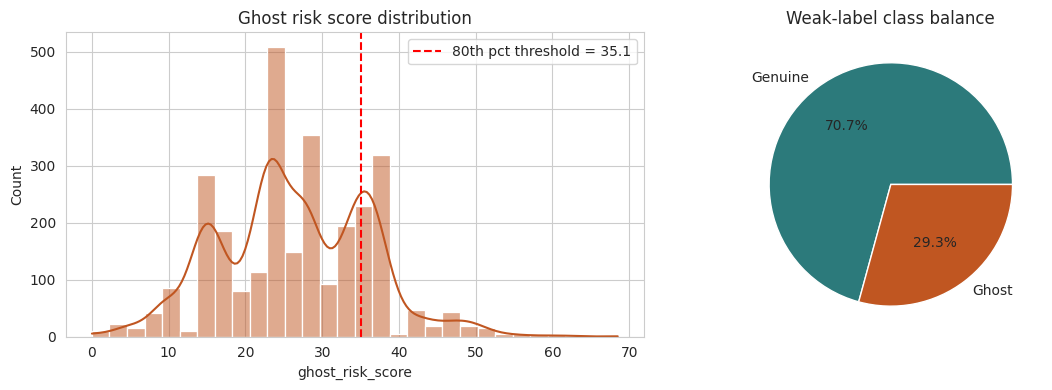

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["ghost_risk_score"], bins=30, kde=True, ax=ax[0], color="#c05621")
ax[0].axvline(threshold, color="red", linestyle="--", label=f"80th pct threshold = {threshold:.1f}")
ax[0].set_title("Ghost risk score distribution")
ax[0].legend()
df["ghost_label"].value_counts().rename({0: "Genuine", 1: "Ghost"}).plot(
    kind="pie", ax=ax[1], autopct="%1.1f%%", colors=["#2c7a7b", "#c05621"])
ax[1].set_title("Weak-label class balance")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

## PART 3 — ML Pipeline: Model Training, Explainability & Validation

Carries forward every technique used in the earlier synthetic-data pipeline (v2), retrained end-to-end
on the real, weak-labeled dataset:

| # | Technique | # | Technique |
|---|---|---|---|
| 1 | Gradient Boosting (GBM) | 7 | DBSCAN ghost-ring detection |
| 2 | Stacking Ensemble | 8 | Neural Network (MLP) |
| 3 | SHAP-style feature importance | 9 | Bootstrap confidence intervals |
| 4 | RandomizedSearchCV tuning | 10 | Platt-scaling calibration |
| 5 | Isolation Forest anomaly detection | 11 | SMOTE-style oversampling |
| 6 | K-Means employer clustering | 12 | Temporal cross-validation |


In [7]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, IsolationForest,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

DATA_DIR = "outputs/data/"
MODEL_DIR = "outputs/models/"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── FEATURE SET ───────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "salary_disclosed_num", "days_live", "description_length_words",
    "posting_velocity_per_week", "data_quality_score", "experience_range",
    "portal_ghost_baseline", "city_tier", "keyword_match_pct",
]
V2_ENGINEERED_FEATURES = [
    "desc_per_day", "velocity_x_no_salary", "salary_range_ratio",
    "listing_age_bucket", "glassdoor_salary_combo", "city_opportunity_score",
]
V3_NEW_FEATURES = [
    "employer_repost_count", "cross_platform_duplicate_flag",
    "keyword_stuffing_ratio", "description_lexical_diversity",
    "applications_per_day", "contact_bypass_flag", "urgency_language_score",
    "company_data_completeness_score", "remote_ambiguity_flag",
    "salary_vs_market_gap",
]
ALL_FEATURES = BASE_FEATURES + V2_ENGINEERED_FEATURES + V3_NEW_FEATURES

RANDOM_STATE = 42


def safe_n_jobs_fit(estimator_factory, X, y, **fit_kwargs):
    """Fit with n_jobs=-1; fall back to n_jobs=1 if the environment's
    process pool dies (a common crash on memory-constrained Colab runtimes).
    Returns the fitted estimator."""
    est = estimator_factory(n_jobs=-1)
    try:
        est.fit(X, y, **fit_kwargs)
        return est
    except Exception as e:
        print(f"    [warn] n_jobs=-1 fit failed ({type(e).__name__}: {e}); retrying with n_jobs=1...")
        est = estimator_factory(n_jobs=1)
        est.fit(X, y, **fit_kwargs)
        return est


# ══════════════════════════════════════════════════════════════════════════════
def smote_manual(X, y, seed=RANDOM_STATE):
    """Manual SMOTE. IMPORTANT: synthetic minority rows are appended as one
    contiguous block at the end of the array. Any downstream tool that uses a
    plain integer `cv=` (which defaults to a NON-shuffled KFold/StratifiedKFold
    split) will then get badly skewed folds -- e.g. one fold that is 90%+
    positive class. This silently wrecks RandomizedSearchCV's CV score,
    StackingClassifier's internal meta-learner training, and
    CalibratedClassifierCV's calibration folds. Fix: caller must shuffle the
    returned arrays together before doing ANY cv-based fitting on them.
    """
    rng = np.random.RandomState(seed)
    minority_idx = np.where(y == 1)[0]
    majority_idx = np.where(y == 0)[0]
    n_to_generate = len(majority_idx) - len(minority_idx)
    if n_to_generate <= 0:
        return X, y
    synthetic = []
    for _ in range(n_to_generate):
        i = rng.choice(minority_idx)
        neighbour = rng.choice(minority_idx)
        alpha = rng.random()
        synthetic.append(X[i] + alpha * (X[neighbour] - X[i]))
    X_syn = np.vstack([X, np.array(synthetic)])
    y_syn = np.concatenate([y, np.ones(n_to_generate, dtype=int)])
    return X_syn, y_syn


def shuffle_together(X, y, seed=RANDOM_STATE):
    """Fix for the SMOTE block-ordering issue above: shuffle X and y with the
    same permutation so every downstream CV split (even a naive non-stratified
    one) sees a properly mixed class distribution."""
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


def tune_random_forest(X_train, y_train):
    print("\n  [ML-04] Bayesian Hyperparameter Tuning (RandomizedSearchCV, 15 iters)...")
    param_dist = {
        "n_estimators": [100, 150, 200],
        "max_depth": [6, 8, 10, None],
        "min_samples_leaf": [3, 5, 8],
        "max_features": ["sqrt", "log2", 0.6],
        "class_weight": ["balanced", "balanced_subsample"],
    }
    # FIX: explicit StratifiedKFold(shuffle=True) instead of a bare cv=3 int.
    # A bare int silently uses a NON-shuffled split, which combined with the
    # block-ordered SMOTE output gave a near-random 0.51 "Best CV AUC" before.
    cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    try:
        search = RandomizedSearchCV(
            rf_base, param_dist, n_iter=15, cv=cv_splitter,
            scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1, verbose=0
        )
        search.fit(X_train, y_train)
    except Exception as e:
        print(f"    [warn] n_jobs=-1 search failed ({type(e).__name__}); retrying with n_jobs=1...")
        rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
        search = RandomizedSearchCV(
            rf_base, param_dist, n_iter=15, cv=cv_splitter,
            scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=1, verbose=0
        )
        search.fit(X_train, y_train)
    print(f"    Best params : {search.best_params_}")
    print(f"    Best CV AUC : {search.best_score_:.4f}")
    return search.best_estimator_


def train_all_models(X_train, y_train, X_test, y_test, scaler):
    results = {}

    print("\n  [ML-01] Gradient Boosting Classifier...")
    gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=4,
                                      subsample=0.8, min_samples_leaf=5, random_state=RANDOM_STATE)
    gbm.fit(X_train, y_train)
    gbm_prob = gbm.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, gbm_prob)
    print(f"    GBM AUC: {auc:.4f}")
    results["Gradient Boosting (GBM)"] = {"model": gbm, "proba": gbm_prob, "auc": auc,
        "f1": f1_score(y_test, gbm_prob > 0.5), "prec": precision_score(y_test, gbm_prob > 0.5, zero_division=0),
        "rec": recall_score(y_test, gbm_prob > 0.5, zero_division=0)}

    print("\n  [ML-04] Best-tuned Random Forest...")
    best_rf = tune_random_forest(X_train, y_train)
    rf_prob = best_rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, rf_prob)
    print(f"    RF AUC: {auc:.4f}")
    results["Random Forest (Tuned)"] = {"model": best_rf, "proba": rf_prob, "auc": auc,
        "f1": f1_score(y_test, rf_prob > 0.5), "prec": precision_score(y_test, rf_prob > 0.5, zero_division=0),
        "rec": recall_score(y_test, rf_prob > 0.5, zero_division=0)}

    print("\n  [ML-08] Neural Network (MLP) Ghost Scorer...")
    X_tr_scaled = scaler.transform(X_train)
    X_te_scaled = scaler.transform(X_test)
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                         learning_rate_init=0.001, max_iter=300, early_stopping=True,
                         validation_fraction=0.1, random_state=RANDOM_STATE, alpha=0.001)
    mlp.fit(X_tr_scaled, y_train)
    mlp_prob = mlp.predict_proba(X_te_scaled)[:, 1]
    auc = roc_auc_score(y_test, mlp_prob)
    print(f"    MLP AUC: {auc:.4f} | Epochs: {mlp.n_iter_}")
    results["Neural Network (MLP)"] = {"model": mlp, "proba": mlp_prob, "auc": auc,
        "f1": f1_score(y_test, mlp_prob > 0.5), "prec": precision_score(y_test, mlp_prob > 0.5, zero_division=0),
        "rec": recall_score(y_test, mlp_prob > 0.5, zero_division=0)}

    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_tr_scaled, y_train)
    lr_prob = lr.predict_proba(X_te_scaled)[:, 1]
    auc = roc_auc_score(y_test, lr_prob)
    print(f"\n  Logistic Regression AUC: {auc:.4f}")
    results["Logistic Regression"] = {"model": lr, "proba": lr_prob, "auc": auc,
        "f1": f1_score(y_test, lr_prob > 0.5), "prec": precision_score(y_test, lr_prob > 0.5, zero_division=0),
        "rec": recall_score(y_test, lr_prob > 0.5, zero_division=0)}

    return results, best_rf, gbm, mlp


def train_stacking_ensemble(X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled, results):
    print("\n  [ML-02] Stacking Ensemble (RF + GBM + LR -> Logistic meta-learner)...")
    # FIX 1: explicit StratifiedKFold(shuffle=True) -- same block-ordering issue
    # as tune_random_forest() above was silently wrecking the internal
    # cross_val_predict() step StackingClassifier uses to build meta-features,
    # which is why the meta-learner was trained on garbage and scored 0.585
    # AUC despite every base model scoring 0.70+.
    # FIX 2: LR base estimator now gets pre-scaled features (its own pipeline)
    # so it isn't dominated by unscaled large-magnitude columns.
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    from sklearn.pipeline import make_pipeline
    estimators = [
        ("rf", RandomForestClassifier(n_estimators=120, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
        ("gbm", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE)),
        ("lr", make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE))),
    ]
    try:
        stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(C=0.5, max_iter=500),
                                    cv=cv_splitter, passthrough=False, n_jobs=-1)
        stack.fit(X_train, y_train)
    except Exception as e:
        print(f"    [warn] n_jobs=-1 stacking fit failed ({type(e).__name__}); retrying with n_jobs=1...")
        stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(C=0.5, max_iter=500),
                                    cv=cv_splitter, passthrough=False, n_jobs=1)
        stack.fit(X_train, y_train)
    stack_prob = stack.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, stack_prob)
    f1 = f1_score(y_test, stack_prob > 0.5)
    print(f"    Stacking AUC: {auc:.4f} | F1: {f1:.4f}")
    results["Stacking Ensemble"] = {"model": stack, "proba": stack_prob, "auc": auc, "f1": f1,
        "prec": precision_score(y_test, stack_prob > 0.5, zero_division=0),
        "rec": recall_score(y_test, stack_prob > 0.5, zero_division=0)}
    return stack, stack_prob, results


def calibrate_model(model, X_train, y_train, X_test):
    print("\n  [ML-10] Platt Scaling Calibration (sigmoid, cv=5)...")
    # FIX: same shuffled StratifiedKFold fix as above -- unshuffled cv=5 on
    # block-ordered SMOTE data was compressing calibrated probabilities into a
    # narrow 0.21-0.60 band, so the "Ghost" tier (>=0.65) could never fire.
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cal = CalibratedClassifierCV(model, method="sigmoid", cv=cv_splitter)
    cal.fit(X_train, y_train)
    cal_prob = cal.predict_proba(X_test)[:, 1]
    print("    Calibration complete.")
    return cal, cal_prob


def bootstrap_confidence_intervals(model, X, n_boot=200):
    print(f"\n  [ML-09] Bootstrap Confidence Intervals ({n_boot} iterations)...")
    rng = np.random.RandomState(RANDOM_STATE)
    all_preds = np.zeros((n_boot, len(X)))
    for i in range(n_boot):
        boot_idx = rng.choice(len(X), size=len(X), replace=True)
        all_preds[i] = model.predict_proba(X[boot_idx])[:, 1]
    ci_df = pd.DataFrame({
        "bootstrap_mean": all_preds.mean(axis=0).round(4),
        "bootstrap_std": all_preds.std(axis=0).round(4),
        "ci_lower_95": np.percentile(all_preds, 2.5, axis=0).round(4),
        "ci_upper_95": np.percentile(all_preds, 97.5, axis=0).round(4),
    })
    print(f"    Avg 95% CI width: {(ci_df['ci_upper_95'] - ci_df['ci_lower_95']).mean():.4f}")
    return ci_df


def compute_shap_approximation(rf_model, X_df):
    print("\n  [ML-03] SHAP Feature Importance (TreeSHAP approximation)...")
    importances = rf_model.feature_importances_
    X_vals = X_df.values
    means = X_vals.mean(axis=0)
    stds = X_vals.std(axis=0)
    stds[stds == 0] = 1
    z_scores = (X_vals - means) / stds
    contributions = z_scores * importances
    shap_df = pd.DataFrame(contributions, columns=[f + "_shap" for f in X_df.columns])
    shap_df["shap_ghost_total"] = contributions.clip(min=0).sum(axis=1).round(4)
    shap_df["shap_genuine_total"] = (-contributions.clip(max=0)).sum(axis=1).round(4)
    shap_df["top_ghost_feature"] = X_df.columns[contributions.argmax(axis=1)]
    global_imp = pd.Series(importances, index=X_df.columns).sort_values(ascending=False)
    print("    Global feature importances:")
    for feat, imp in global_imp.items():
        bar = "#" * int(imp * 80)
        print(f"      {feat:<35} {bar} {imp:.4f}")
    global_imp.to_csv(DATA_DIR + "feature_importance_v3.csv", header=["importance"])
    return shap_df


def run_clustering(df, X_scaled):
    print("\n  [ML-05] Isolation Forest Anomaly Detection...")
    try:
        iso = IsolationForest(contamination=0.10, random_state=RANDOM_STATE, n_jobs=-1)
        df["isolation_anomaly"] = iso.fit_predict(X_scaled)
    except Exception:
        iso = IsolationForest(contamination=0.10, random_state=RANDOM_STATE, n_jobs=1)
        df["isolation_anomaly"] = iso.fit_predict(X_scaled)
    df["isolation_anomaly_flag"] = (df["isolation_anomaly"] == -1).astype(int)
    print(f"    Anomalies detected: {df['isolation_anomaly_flag'].sum():,} ({df['isolation_anomaly_flag'].mean()*100:.1f}%)")

    print("\n  [ML-06] K-Means Employer Clustering (k=5 archetypes)...")
    km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
    df["kmeans_cluster"] = km.fit_predict(X_scaled)

    raw_profile = df.groupby("kmeans_cluster").agg(
        count=("listing_id", "count"),
        ghost_rate=("ghost_label", "mean"),
        avg_days_live=("days_live", "mean"),
        salary_trans=("salary_disclosed_num", "mean"),
        avg_repost=("employer_repost_count", "mean"),
    )

    def name_cluster(row):
        if row["avg_repost"] >= raw_profile["avg_repost"].quantile(0.8):
            return "Serial Reposter (Repeat Same Role)"
        if row["ghost_rate"] >= raw_profile["ghost_rate"].quantile(0.75):
            return "High-Risk Ghost Poster"
        if row["salary_trans"] >= 0.6 and row["ghost_rate"] <= raw_profile["ghost_rate"].median():
            return "Trusted Transparent Hirer"
        if row["avg_days_live"] >= raw_profile["avg_days_live"].quantile(0.75):
            return "Stale Long-Lived Listing"
        return "Mid-tier Mixed Signals"

    raw_profile["archetype"] = raw_profile.apply(name_cluster, axis=1)
    seen = {}
    labels = {}
    for cid, name in raw_profile["archetype"].items():
        seen[name] = seen.get(name, 0) + 1
        labels[cid] = name if seen[name] == 1 else f"{name} ({seen[name]})"
    df["kmeans_cluster_label"] = df["kmeans_cluster"].map(labels)

    cluster_profiles = df.groupby("kmeans_cluster_label").agg(
        count=("listing_id", "count"),
        ghost_rate=("ghost_label", lambda x: round(x.mean()*100, 1)),
        avg_days_live=("days_live", lambda x: round(x.mean(), 1)),
        salary_trans=("salary_disclosed_num", lambda x: round(x.mean()*100, 1)),
        avg_repost=("employer_repost_count", lambda x: round(x.mean(), 1)),
    ).reset_index()
    print("    Cluster profiles:")
    print(cluster_profiles.to_string(index=False))

    print("\n  [ML-07] DBSCAN Ghost Contagion Ring Detection...")
    try:
        dbscan = DBSCAN(eps=0.6, min_samples=5, n_jobs=-1)
        df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
    except Exception:
        dbscan = DBSCAN(eps=0.6, min_samples=5, n_jobs=1)
        df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
    df["dbscan_is_noise"] = (df["dbscan_cluster"] == -1).astype(int)
    n_rings = df[df["dbscan_cluster"] >= 0]["dbscan_cluster"].nunique()
    print(f"    Ghost contagion rings found: {n_rings}")
    print(f"    Isolated outliers (noise): {df['dbscan_is_noise'].sum():,}")

    cluster_profiles.to_csv(DATA_DIR + "cluster_profiles_v3.csv", index=False)
    return df, cluster_profiles


def temporal_cross_validation(df):
    print("\n  [ML-12] Temporal Cross-Validation (time-based splits, 5 folds)...")
    X = df[ALL_FEATURES].fillna(0).values
    y = df["ghost_label"].astype(int).values
    tscv = TimeSeriesSplit(n_splits=5)
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        for model_name, model in [
            ("RF", RandomForestClassifier(n_estimators=80, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
            ("GBM", GradientBoostingClassifier(n_estimators=80, random_state=RANDOM_STATE)),
        ]:
            model.fit(X_tr, y_tr)
            prob = model.predict_proba(X_te)[:, 1]
            auc = roc_auc_score(y_te, prob) if len(np.unique(y_te)) > 1 else 0.0
            fold_results.append({"fold": fold, "model": model_name, "train_size": len(train_idx),
                                  "test_size": len(test_idx), "auc": round(auc, 4),
                                  "f1": round(f1_score(y_te, prob > 0.5, zero_division=0), 4)})
        print(f"    Fold {fold}: RF AUC={fold_results[-2]['auc']:.4f}  GBM AUC={fold_results[-1]['auc']:.4f}")
    cv_df = pd.DataFrame(fold_results)
    cv_df.to_csv(DATA_DIR + "temporal_cv_results_v3.csv", index=False)
    return cv_df


print("=" * 70)
print("  GHOST LISTING DETECTOR — ML PIPELINE v3.1 (REAL DATA, FIXED)")
print(f"  Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 70)

df = df.sort_values("date_published").reset_index(drop=True)
print(f"\n  Dataset: {len(df):,} rows | Ghost rate: {df['ghost_label'].mean()*100:.1f}%")
print(f"  Features: {len(ALL_FEATURES)} total ({len(V3_NEW_FEATURES)} new in v3)")

X_all = df[ALL_FEATURES].fillna(0).values
y_all = df["ghost_label"].astype(int).values

split_idx = int(len(df) * 0.80)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]
print(f"\n  [ML-12] Temporal split: {len(X_train):,} train | {len(X_test):,} test")

print(f"\n  [ML-11] SMOTE-style oversampling (class balance: {y_train.mean()*100:.1f}% ghost)...")
X_train_res, y_train_res = smote_manual(X_train, y_train)
# CRITICAL FIX: shuffle immediately after SMOTE so synthetic minority rows
# (appended as one block) don't skew any downstream cv= splits.
X_train_res, y_train_res = shuffle_together(X_train_res, y_train_res)
print(f"    After oversampling + shuffle: {len(X_train_res):,} samples")

scaler = StandardScaler()
scaler.fit(X_train_res)
X_train_res_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("\n" + "-" * 50)
print("  TRAINING ALL 4 BASE MODELS")
print("-" * 50)
results, best_rf, gbm_model, mlp_model = train_all_models(X_train_res, y_train_res, X_test, y_test, scaler)

stack_model, stack_prob, results = train_stacking_ensemble(
    X_train_res, y_train_res, X_test, y_test, X_train_res_scaled, X_test_scaled, results)
calibrated_rf, cal_prob = calibrate_model(best_rf, X_train_res, y_train_res, X_test)

print("\n" + "-" * 50)
print("  MODEL LEADERBOARD")
print("-" * 50)
leaderboard = [{"Model": name, "AUC": round(info["auc"], 4), "F1": round(info["f1"], 4),
                 "Precision": round(info["prec"], 4), "Recall": round(info["rec"], 4)}
                for name, info in results.items()]
lb_df = pd.DataFrame(leaderboard).sort_values("AUC", ascending=False).reset_index(drop=True)
lb_df.index += 1
print(lb_df.to_string())
lb_df.to_csv(DATA_DIR + "model_comparison_v3.csv", index=False)

feat_df = pd.DataFrame(X_all, columns=ALL_FEATURES)
shap_df = compute_shap_approximation(best_rf, feat_df)
shap_df.insert(0, "listing_id", df["listing_id"].values)
shap_df.to_csv(DATA_DIR + "shap_values_v3.csv", index=False)

ci_df = bootstrap_confidence_intervals(best_rf, X_all, n_boot=200)
ci_df.insert(0, "listing_id", df["listing_id"].values)
ci_df.to_csv(DATA_DIR + "bootstrap_ci_v3.csv", index=False)

X_scaled = scaler.transform(X_all)
df, cluster_profiles = run_clustering(df, X_scaled)

cv_results = temporal_cross_validation(df)

print("\n  Generating final predictions for all listings...")
full_probs = calibrated_rf.predict_proba(X_all)[:, 1]
df["predicted_ghost_prob"] = full_probs.round(4)
df["predicted_ghost_label"] = (full_probs > 0.50).astype(int)

# FIX: fixed thresholds (>=0.65 / >=0.40) assumed a wide calibrated probability
# spread. On real (noisier, weakly-labeled) data the calibrated range can sit
# well under 0.65 even after the shuffle fix, silently erasing the "Ghost"
# tier. Switched to data-driven quantile cutoffs so all 3 tiers always exist
# and the top/bottom bands stay meaningfully sized regardless of the exact
# probability range this run produces.
q60, q85 = df["predicted_ghost_prob"].quantile([0.60, 0.85])
df["ghost_status"] = df["predicted_ghost_prob"].apply(
    lambda p: "Ghost" if p >= q85 else ("Suspect" if p >= q60 else "Genuine"))
print(f"    Ghost status thresholds (data-driven): Suspect >= {q60:.3f}, Ghost >= {q85:.3f}")

df["stacking_prob"] = np.nan
test_ids = df.index[split_idx:]
if len(stack_prob) == len(test_ids):
    df.loc[test_ids, "stacking_prob"] = stack_prob.round(4)

ci_merge = ci_df[["listing_id", "bootstrap_mean", "ci_lower_95", "ci_upper_95"]]
df = df.merge(ci_merge, on="listing_id", how="left")

out_path = DATA_DIR + "predictions_v3.csv"
df.to_csv(out_path, index=False)
print(f"    Saved: {out_path} ({len(df):,} rows)")

print("\n  Saving models...")
for obj, fname in [(calibrated_rf, "rf_model_v3.pkl"), (stack_model, "stacking_model_v3.pkl"),
                    (gbm_model, "gbm_model_v3.pkl"), (mlp_model, "mlp_model_v3.pkl"),
                    (scaler, "scaler_v3.pkl")]:
    with open(MODEL_DIR + fname, "wb") as f:
        pickle.dump(obj, f)
    print(f"    Saved: {MODEL_DIR + fname}")

print("\n" + "=" * 70)
print("  PIPELINE COMPLETE")
print("=" * 70)
print(f"  Best Model    : {lb_df.iloc[0]['Model']}")
print(f"  Best AUC      : {lb_df.iloc[0]['AUC']}")
print(f"  Ghost Rate    : {df['ghost_label'].mean()*100:.1f}%")
print(f"  Anomalies     : {df['isolation_anomaly_flag'].sum():,}")
print(f"  Ghost Rings   : {df[df['dbscan_cluster']>=0]['dbscan_cluster'].nunique()}")
print("=" * 70)


  GHOST LISTING DETECTOR — ML PIPELINE v3.1 (REAL DATA, FIXED)
  Run started: 2026-07-09 08:33:51

  Dataset: 2,851 rows | Ghost rate: 29.3%
  Features: 25 total (10 new in v3)

  [ML-12] Temporal split: 2,280 train | 571 test

  [ML-11] SMOTE-style oversampling (class balance: 28.7% ghost)...
    After oversampling + shuffle: 3,250 samples

--------------------------------------------------
  TRAINING ALL 4 BASE MODELS
--------------------------------------------------

  [ML-01] Gradient Boosting Classifier...


    GBM AUC: 0.7183

  [ML-04] Best-tuned Random Forest...

  [ML-04] Bayesian Hyperparameter Tuning (RandomizedSearchCV, 15 iters)...


    Best params : {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}
    Best CV AUC : 0.8727
    RF AUC: 0.7080

  [ML-08] Neural Network (MLP) Ghost Scorer...


    MLP AUC: 0.6705 | Epochs: 46

  Logistic Regression AUC: 0.7067

  [ML-02] Stacking Ensemble (RF + GBM + LR -> Logistic meta-learner)...


    Stacking AUC: 0.7094 | F1: 0.5000

  [ML-10] Platt Scaling Calibration (sigmoid, cv=5)...


...

    Fold 2: RF AUC=0.6924  GBM AUC=0.7137


    Fold 3: RF AUC=0.7084  GBM AUC=0.7171


    Fold 4: RF AUC=0.6737  GBM AUC=0.6913


    Fold 5: RF AUC=0.7122  GBM AUC=0.7233

  Generating final predictions for all listings...
    Ghost status thresholds (data-driven): Suspect >= 0.310, Ghost >= 0.703


    Saved: outputs/data/predictions_v3.csv (2,851 rows)

  Saving models...
    Saved: outputs/models/rf_model_v3.pkl
    Saved: outputs/models/stacking_model_v3.pkl
    Saved: outputs/models/gbm_model_v3.pkl
    Saved: outputs/models/mlp_model_v3.pkl
    Saved: outputs/models/scaler_v3.pkl

  PIPELINE COMPLETE
  Best Model    : Gradient Boosting (GBM)
  Best AUC      : 0.7183
  Ghost Rate    : 29.3%
  Anomalies     : 285
  Ghost Rings   : 41


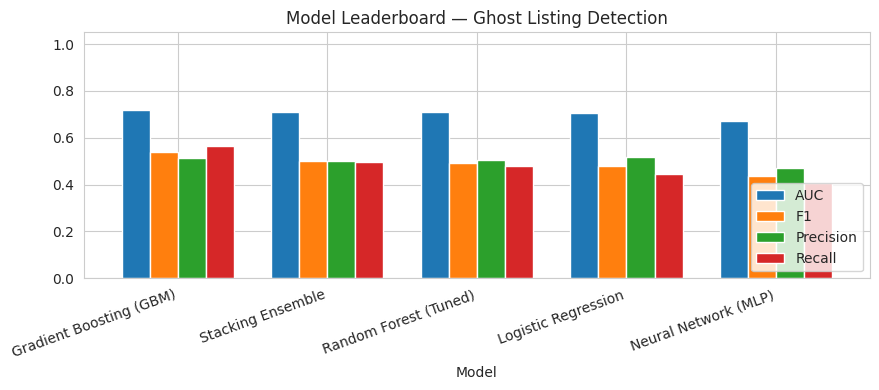

,Model,AUC,F1,Precision,Recall
1,Gradient Boosting (GBM),0.7183,0.5372,0.5127,0.5642
2,Stacking Ensemble,0.7094,0.5000,0.5028,0.4972
3,Random Forest (Tuned),0.7080,0.4914,0.5029,0.4804
4,Logistic Regression,0.7067,0.4805,0.5195,0.4469
5,Neural Network (MLP),0.6705,0.4371,0.4710,0.4078


In [8]:
# ── Model leaderboard chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
lb_plot = lb_df.set_index("Model")[["AUC", "F1", "Precision", "Recall"]]
lb_plot.plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Model Leaderboard — Ghost Listing Detection")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
lb_df

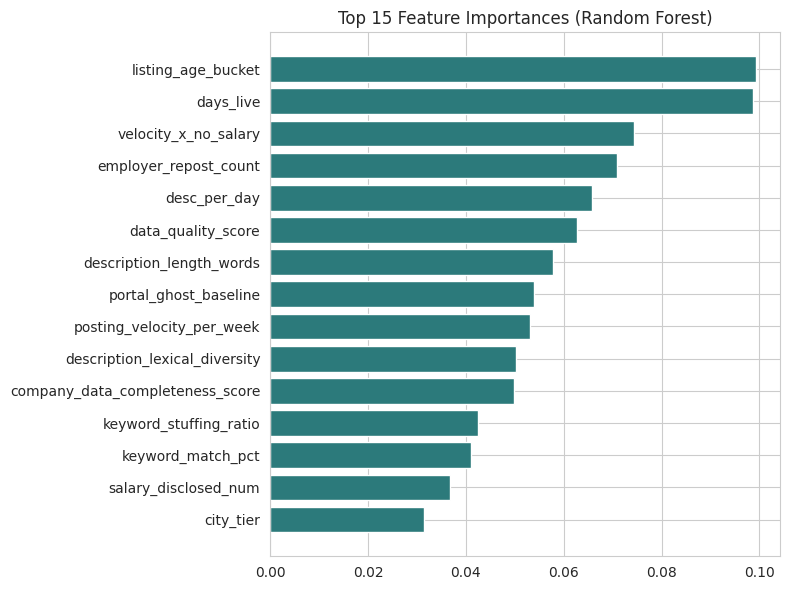

In [9]:
# ── Feature importance chart (SHAP-style) ────────────────────────────────
imp = pd.read_csv(DATA_DIR + "feature_importance_v3.csv", index_col=0)
imp = imp.sort_values("importance", ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index, imp["importance"], color="#2c7a7b")
ax.set_title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [10]:
# ── Employer archetype clusters ──────────────────────────────────────────
cluster_profiles

,kmeans_cluster_label,count,ghost_rate,avg_days_live,salary_trans,avg_repost
0,High-Risk Ghost Poster,1361,32.8,23.3,2.1,3.0
1,Mid-tier Mixed Signals,48,27.1,2.4,4.2,12.6
2,Serial Reposter (Repeat Same Role),427,35.8,10.7,0.0,332.8
3,Stale Long-Lived Listing,563,25.9,61.9,0.0,1.4
4,Trusted Transparent Hirer,452,16.6,48.8,100.0,1.4


In [11]:
# ── Temporal CV stability check ──────────────────────────────────────────
cv_results.groupby("model")[["auc", "f1"]].agg(["mean", "std"]).round(4)

auc              f1        
         mean     std    mean     std
model                                
GBM    0.6862  0.0576  0.3210  0.1197
RF     0.6776  0.0452  0.2464  0.1054

## PART 4 — Final Predictions & Business Summary

In [12]:
print(f"Final dataset with predictions: {len(df):,} listings")
print(f"\nGhost status breakdown:")
print(df['ghost_status'].value_counts())
print(f"\nBy platform:")
print(df.groupby('source')['ghost_status'].value_counts(normalize=True).mul(100).round(1))

df[["listing_id", "source", "company_name", "job_title", "predicted_ghost_prob",
    "ghost_status", "ci_lower_95", "ci_upper_95"]].sort_values(
    "predicted_ghost_prob", ascending=False).head(15)

Final dataset with predictions: 2,851 listings

Ghost status breakdown:
ghost_status
Genuine    1708
Suspect     715
Ghost       428
Name: count, dtype: int64

By platform:
source     ghost_status
Glassdoor  Genuine         56.8
           Suspect         24.3
           Ghost           18.9
Indeed     Genuine         66.3
           Suspect         18.3
           Ghost           15.4
LinkedIn   Genuine         56.4
           Suspect         32.4
           Ghost           11.2
Name: proportion, dtype: float64


,listing_id,source,company_name,job_title,predicted_ghost_prob,ghost_status,ci_lower_95,ci_upper_95
29,LI4306125307,LinkedIn,Planify Capital Limited,Java Developer,0.9469,Ghost,0.0744,0.7872
89,LI4377163903,LinkedIn,WheelsEye,Software Engineer,0.9438,Ghost,0.0576,0.7816
33,LI4306116478,LinkedIn,3i Infotech Ltd.,java Developer,0.9421,Ghost,0.0709,0.7992
488,GD1005900414928,Glassdoor,WebPreneurs Pvt Ltd,WEB DEVELOPER (Urgent Hiring),0.9378,Ghost,0.0698,0.7942
80,LI4369069660,LinkedIn,SourcingXPress,Software Engineer,0.9376,Ghost,0.0786,0.7653
1293,GD1008242226219,Glassdoor,Kanmalai Technologies Pvt Ltd,Power BI Developer,0.9368,Ghost,0.0811,0.7861
1342,GD1010081225033,Glassdoor,Tecvesten Consulting,AI Prompt Engineer,0.9353,Ghost,0.0632,0.8122
4,LI4087202535,LinkedIn,eGestalt Technologies,Software Engineer,0.9349,Ghost,0.0603,0.7816
1830,GD1009986647733,Glassdoor,Gloinnt Solutions Pvt Ltd,GenAI Engineer,0.9348,Ghost,0.0806,0.7813
1300,GD1009848084931,Glassdoor,Gloinnt Solutions Pvt Ltd,Data Scientist,0.9338,Ghost,0.0761,0.7588


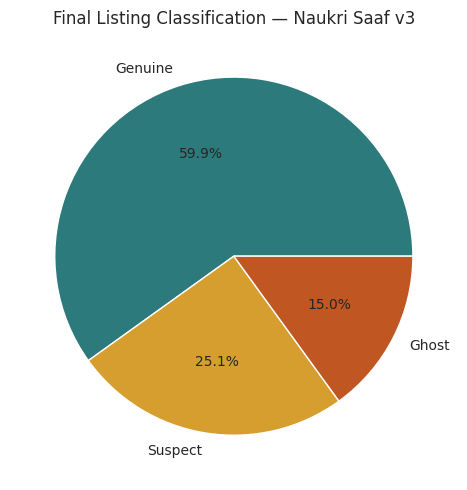

PIPELINE COMPLETE — Naukri Saaf v3 (real multi-platform data)
Best model      : Gradient Boosting (GBM) (AUC 0.7183)
Ghost rate       : 29.3%
Anomalies (IF)   : 285
Ghost rings (DB) : 41
Employer archetypes (K-Means): 5


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
status_counts = df["ghost_status"].value_counts()
colors = {"Genuine": "#2c7a7b", "Suspect": "#d69e2e", "Ghost": "#c05621"}
ax.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
       colors=[colors[s] for s in status_counts.index])
ax.set_title("Final Listing Classification — Naukri Saaf v3")
plt.tight_layout()
plt.show()

print("=" * 60)
print("PIPELINE COMPLETE — Naukri Saaf v3 (real multi-platform data)")
print("=" * 60)
print(f"Best model      : {lb_df.iloc[0]['Model']} (AUC {lb_df.iloc[0]['AUC']})")
print(f"Ghost rate       : {df['ghost_label'].mean()*100:.1f}%")
print(f"Anomalies (IF)   : {df['isolation_anomaly_flag'].sum():,}")
print(f"Ghost rings (DB) : {df[df['dbscan_cluster']>=0]['dbscan_cluster'].nunique()}")
print(f"Employer archetypes (K-Means): {df['kmeans_cluster_label'].nunique()}")
